# Tuning report — interactive plots

Per-animal place-and-reward cell tuning diagnostics across a chronological session range. The selection cell in section 2 is the only thing to edit when switching datasets, animals, sessions, or trial types; everything downstream — load and the per-session outputs — works against whatever the selection cell defined. Section 4 cells are thin caller stubs over `sollertia_forgery.analysis.tuning.plotting`; edit the helpers in the package and re-run the affected cell to refresh.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running the section 4 cells picks up plotting helper changes without reloading.

In [23]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import cmocean
from ataraxis_base_utilities import LogLevel, console

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    TuningReport,
    plot_classified_heatmap,
    plot_cue_pair_place_counts,
    plot_sorted_heatmap,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Selection

The only cell to edit when switching datasets, animals, sessions, or trial types. `DATASET_PATH` is the dataset root, `ANIMAL` is a single animal id, `DISPLAY_SESSIONS` is a tuple of 1-indexed chronological session numbers shared by every per-session plot below (`None` renders every session in the animal's list), and `TRIAL_TYPE` selects which trial type the per-session plots evaluate (set to `None` to fall back to the first trial type in each helper's own resolution path).

In [24]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMAL: str = "11"
DISPLAY_SESSIONS: tuple[int, ...] | None = (15,16,17,18,19,20)
TRIAL_TYPE: str | None = None

## 3. Load

Reads the dataset, builds the chronologically sorted `sessions` tuple for the selected animal, and echoes a banner summarizing the resolved selection. The per-session plots in section 4 read `sessions`, `DISPLAY_SESSIONS`, and `trial_type` directly.

In [25]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
sessions = tuple(
    sorted(
        dataset.get_sessions_for_animal(animal=ANIMAL),
        key=lambda dataset_session: dataset_session.session,
    )
)
trial_type: str | None = TRIAL_TYPE

console.echo(message=f"Dataset: {dataset.name} ({DATASET_PATH})", level=LogLevel.INFO)
console.echo(
    message=(
        f"Animal {ANIMAL}, {len(sessions)} sessions available; "
        f"display={DISPLAY_SESSIONS if DISPLAY_SESSIONS is not None else 'all'}; "
        f"trial type {trial_type!r}"
    ),
    level=LogLevel.INFO,
)

2026-05-03 12:33:52.658 | INFO     | Dataset: void (/home/data/Data/void)
2026-05-03 12:33:52.659 | INFO     | Animal 15, 20 sessions available; display=(15, 16, 17, 18, 19, 20); trial type None


## 4. Per-session outputs

Each cell below calls one helper from `sollertia_forgery.analysis.tuning.plotting` against `sessions` and `trial_type`, restricted to `DISPLAY_SESSIONS`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Text summary

Iterates the resolved display sessions and prints each session's `TuningReport.summarize()` block.

In [26]:
selected_indices = (
    list(range(len(sessions)))
    if DISPLAY_SESSIONS is None
    else sorted({int(n) - 1 for n in DISPLAY_SESSIONS if 0 <= int(n) - 1 < len(sessions)})
)
for sess_idx in selected_indices:
    sess = sessions[sess_idx]
    console.echo(
        message=f"Animal {ANIMAL} session [{sess_idx + 1}] {sess.session} tuning summary",
        level=LogLevel.INFO,
    )
    console.echo(message=TuningReport.load(session=sess).summarize(), raw=True)

2026-05-03 12:33:52.706 | INFO     | Animal 15 session [15] 2025-08-01-11-57-36-722404 tuning summary
Tuning report
Cells: 3836
Trial types: cyclic_4_cue
Sampling rate: 10.00 Hz

Trial type: cyclic_4_cue
------------------------
  Track length:      240.0 cm
  Reward position:   225.0 cm
  Bin size:          5.0 cm (48 bins)
  Place-only:            2255 (58.8%)
  Reliable (lap cov.):   2700 (70.4%)
  Stable (split-half):   3578 (93.3%)
  Peak-significant:      3421 (89.2%)
  Strict place cells:    2491 (64.9%)
  Spatially significant: 3812 (99.4%)
  Reward cells:          661 (17.2%)
  Reward-predictive:     63 (1.6%)
  Reward mixture: weight 0.128, center 206.0 cm (SD 14.8 cm)
  Track-start wt: 0.000 (SD 11.1 cm)
  Track-end wt:   0.000 (SD 11.8 cm)
2026-05-03 12:33:52.769 | INFO     | Animal 15 session [16] 2025-08-04-16-10-39-236071 tuning summary
Tuning report
Cells: 3836
Trial types: cyclic_4_cue
Sampling rate: 10.00 Hz

Trial type: cyclic_4_cue
------------------------
  Track l

### 4.8 Per-day-sorted rate maps across the animal — all cells

Per-session view across the animal's full session list: every registered cell renders as a row, sorted independently by *that session's* peak position. Rate maps are raw ΔF/F₀ on a shared percentile-clipped color scale so amplitudes are directly comparable between panels. Use this view for a global sense of the population's tuning band; pair with section 4.9 for the active-cell only band.

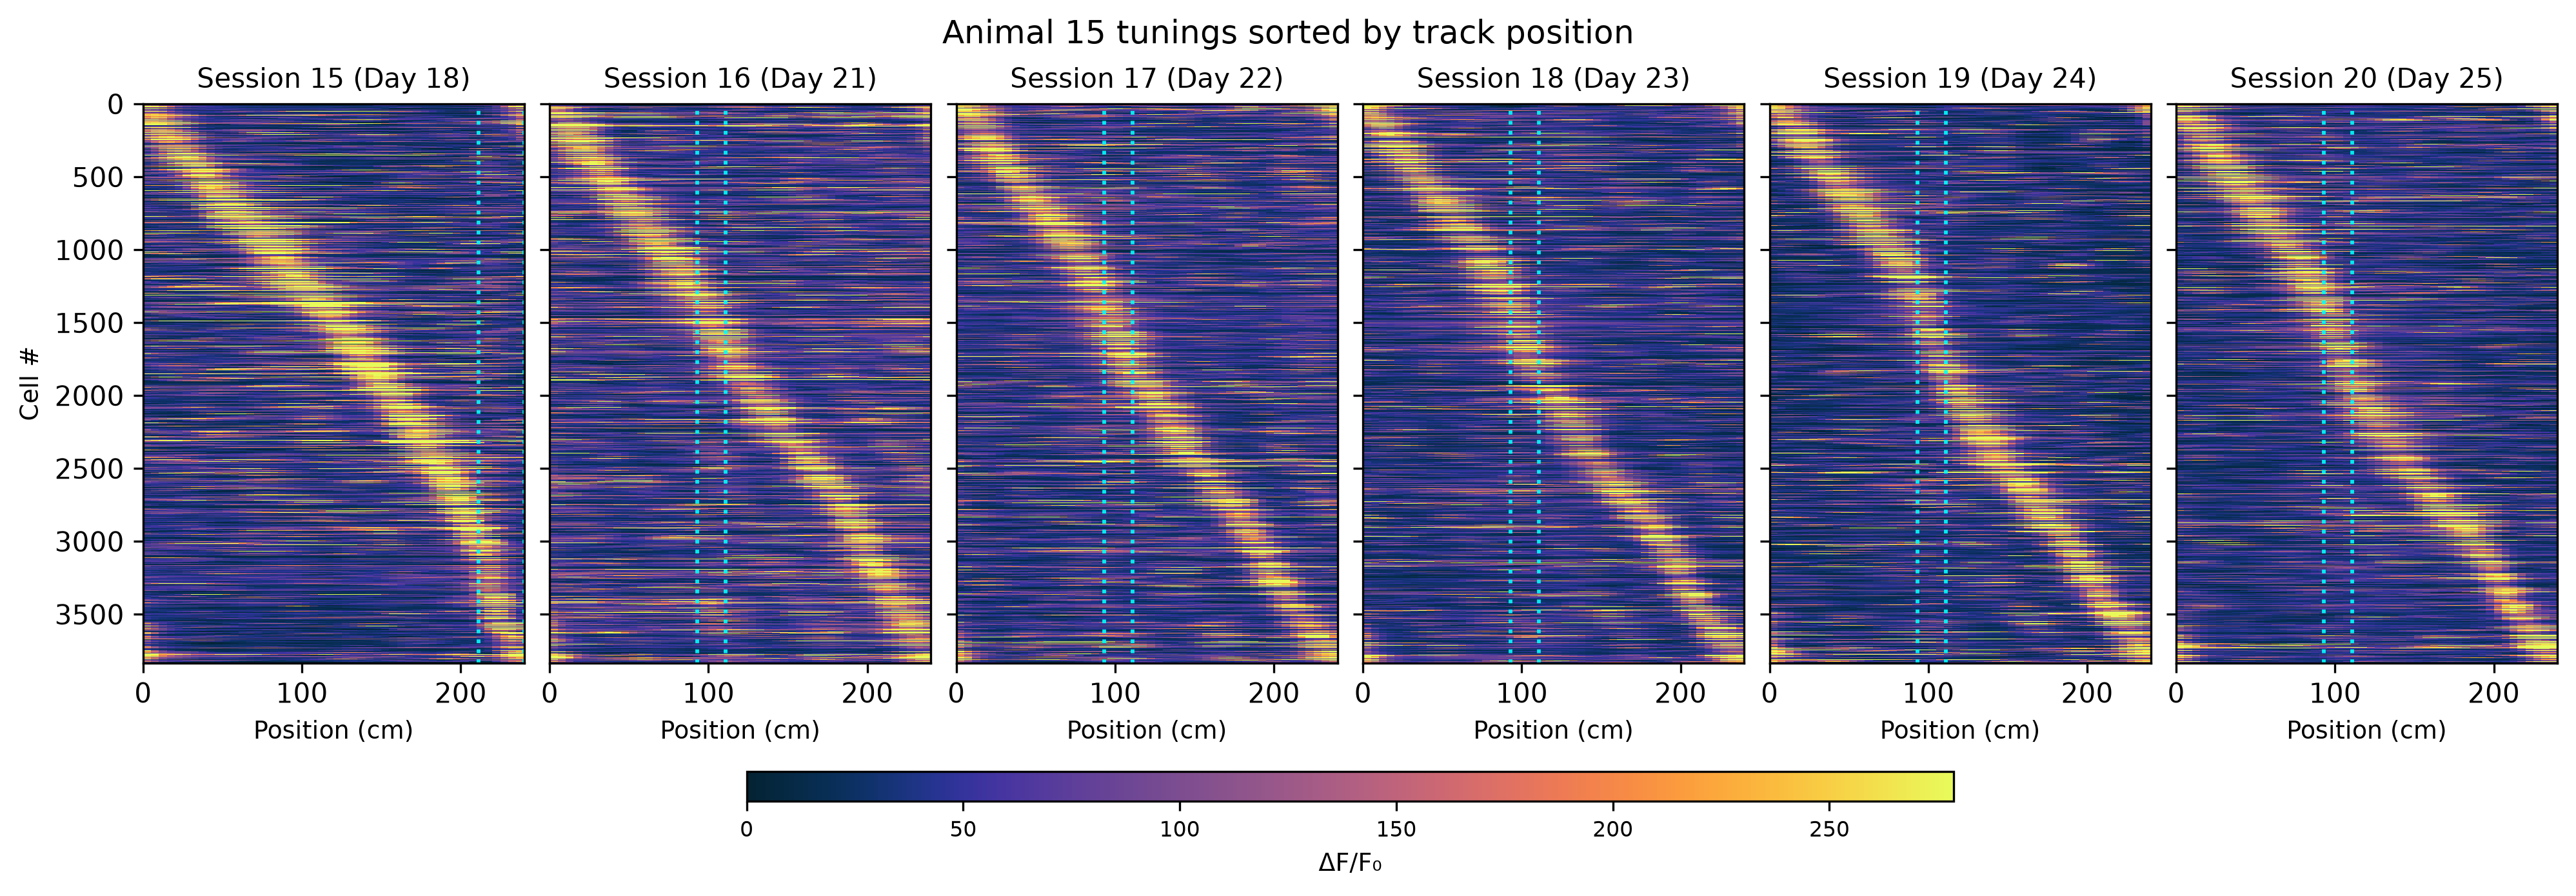

In [27]:
plot_sorted_heatmap(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=300,
    cmap="cmo.thermal",
)
plt.show()

### 4.9 Per-day-sorted rate maps across the animal — classified cells

Per-session view restricted to one classifier-active subset. ``classifier="place"`` always selects ``IS_STRICT_PLACE`` (place-field morphology + lap coverage + split-half stability + per-cell peak shuffle); ``classifier="reward"`` selects ``IS_REWARD_CELL``. Each cell's row is divided by its own peak so the colorbar is fixed at ``[0, 1]`` regardless of absolute ΔF/F₀ amplitude. Cell counts vary across panels (the active set differs by day), so the y-axis is tickless and the per-panel ``Session X (Day Y, n=N)`` title carries the count.

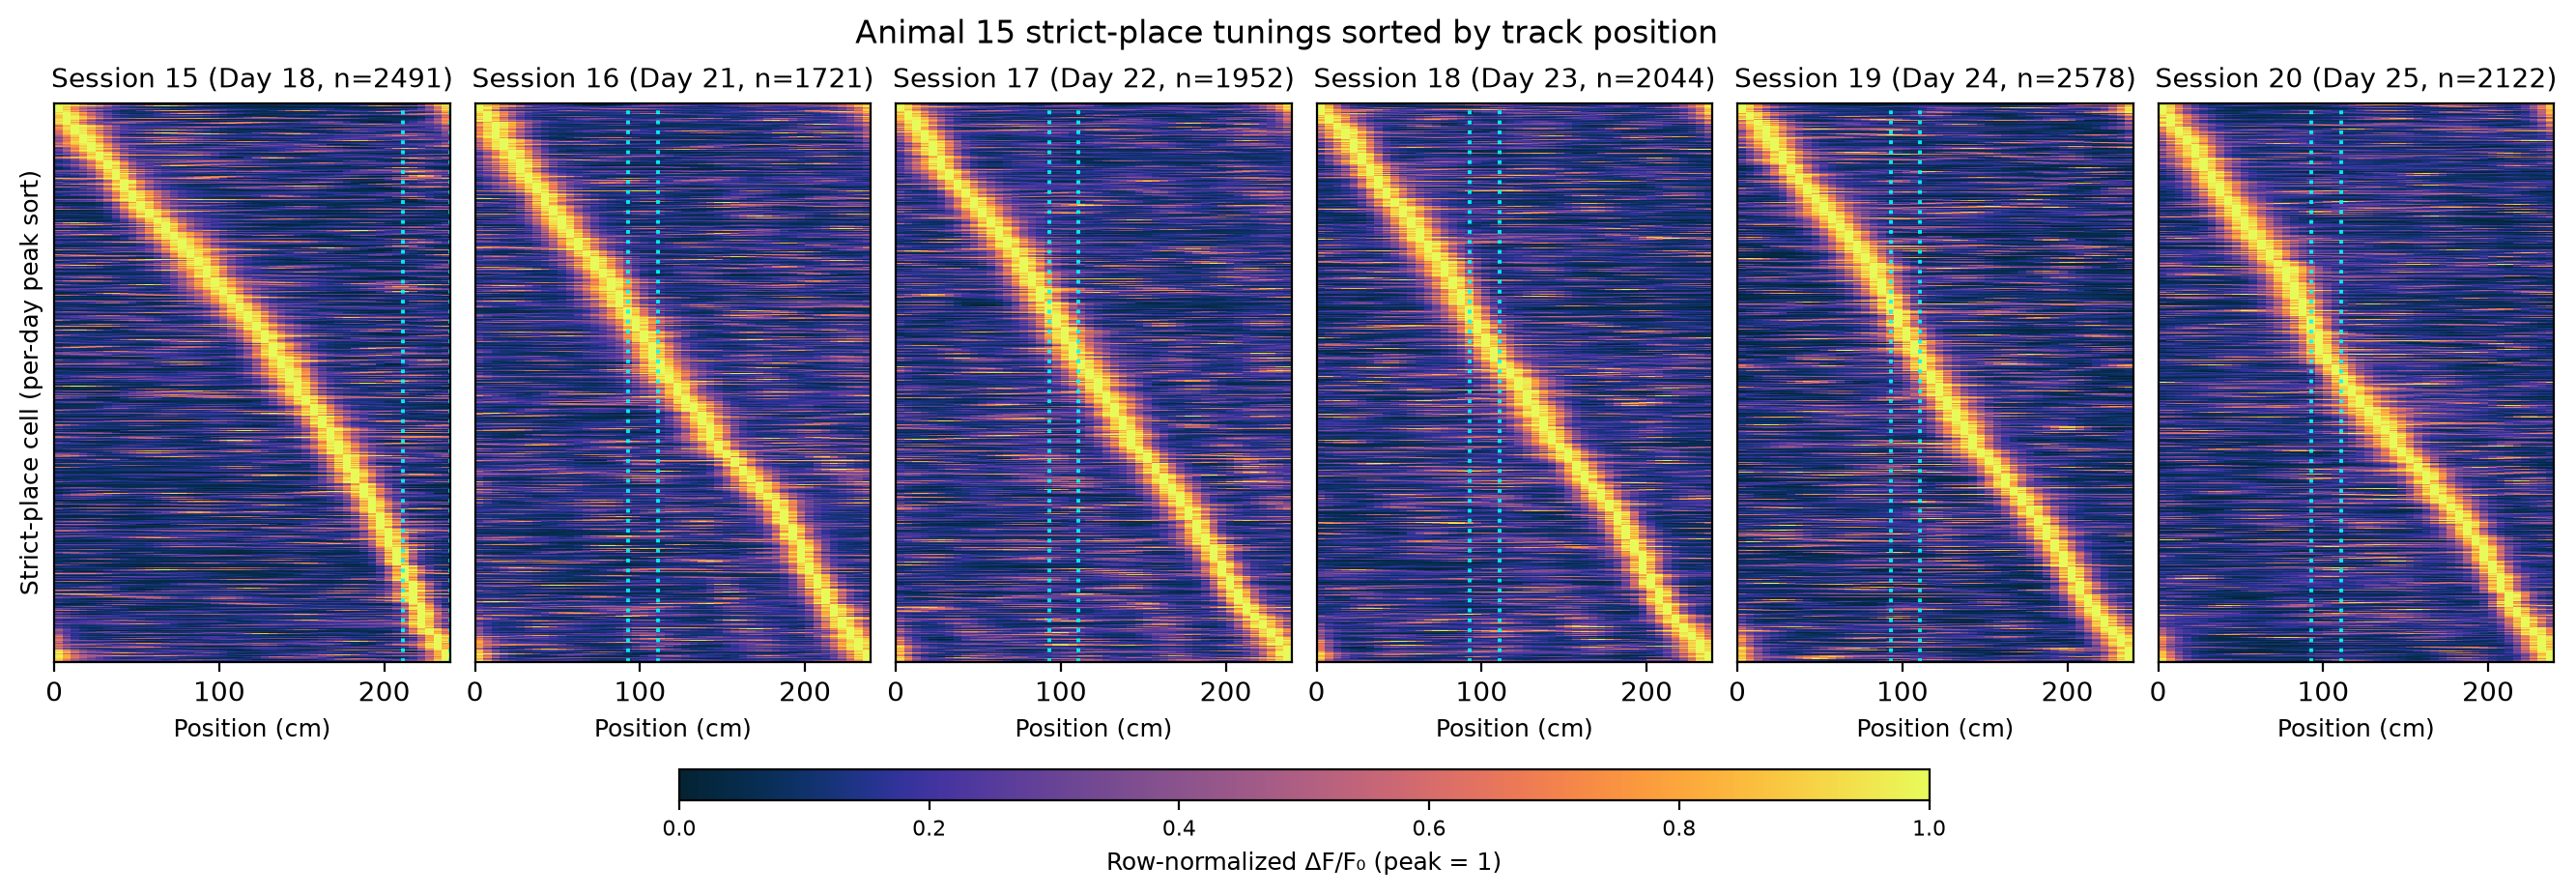

In [28]:
plot_classified_heatmap(
    sessions=sessions,
    classifier="place",  # "place" → IS_STRICT_PLACE; switch to "reward" for IS_REWARD_CELL
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=200,
    cmap="cmo.thermal",
)
plt.show()

### 4.10 Strict-place cells per cue-gray pair

Per-session bar chart of strict-place cell counts binned into ``n_cue_pairs`` uniform-length cue-gray pairs (default 4 — match your trial type). Bars are labelled ``<pair_index>-0`` and pairwise two-sided binomial tests draw thin black ``ns`` brackets above the bars whose ``counts[i] ~ Binomial(counts[i] + counts[j], 0.5)`` null is *not* rejected at p < 0.05; significant pairs render bare. No multiple-comparison correction is applied — interpret with care when ``n_cue_pairs`` is large.

Uses `DISPLAY_SESSIONS` from the selection cell to pick which sessions to render.

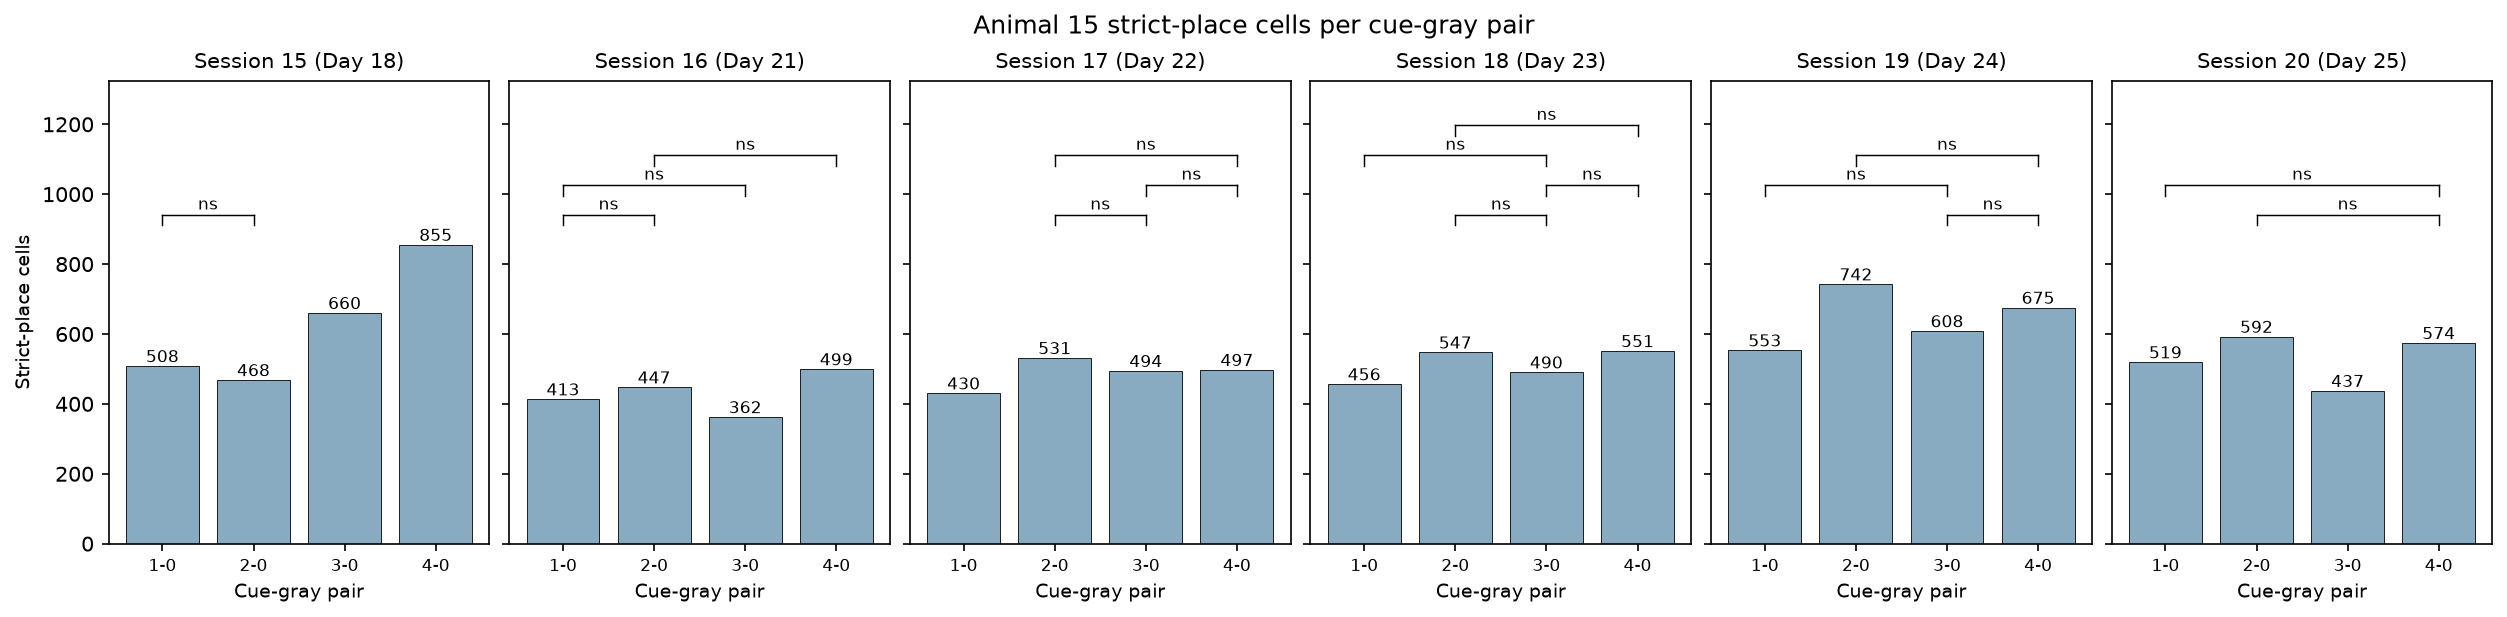

In [29]:
plot_cue_pair_place_counts(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=150,
)
plt.show()